**STRATEGIC SALES ANALYSIS & ANOMALY DETECTION: UK E-COMMERCE INSIGHTS (2010-2011)**

📌 **Deskripsi:**

Melakukan analisis mendalam terhadap dataset transaksi ritel online dari perusahaan e-commerce yang berbasis di Inggris (UK) untuk periode Desember 2010 hingga Desember 2011. Analisis ini dirancang untuk mengevaluasi kesehatan bisnis, memahami pola perilaku konsumen, dan mengidentifikasi risiko operasional melalui data.

📊 **Studi Kasus:**


Perusahaan ingin mengoptimalkan strategi tahun depan dengan mempelajari histori transaksi.
Fokus utama mencakup pemetaan tren musiman, identifikasi produk "bintang" vs produk yang tidak laku, serta pelacakan anomali transaksi (pembatalan dan pesanan partai besar).

**⚙️ Metodologi & Fitur Kode :**

Analisis dibagi menjadi 4 tahapan utama yang direpresentasikan dalam blok kode terpisah:
- **Data Preparation & Cleaning:** Menangani missing values, memformat tanggal ke standar "Nama Bulan-Tahun", serta menciptakan metrik Revenue (Quantity*Price).

- **Monthly Sales Trend:** Visualisasi fluktuasi pendapatan bulanan untuk melihat pengaruh musim (seasonality).

- **Product Performance Analysis:** Visualisasi menggunakan grafik dinamis untuk Produk Terlaris tiap bulan dan Grafik khusus untuk Produk dengan Penjualan Terendah guna evaluasi stok gudang.

- **Anomaly & Outlier Detection:** Analisis transaksi negatif (Retur/Pembatalan).Deteksi Outlier menggunakan Scatter Plot untuk mengidentifikasi pembeli VIP atau pesanan partai besar.

💡 **Temuan Utama (Key Insights):**

1. **Peak Season:** Penjualan mencapai puncak tertinggi pada November 2011 akibat persiapan liburan akhir tahun.
2. **Data Cut-off Anomaly:** Penurunan drastis pada Desember 2011 diidentifikasi sebagai anomali data (perekaman data terhenti pada tanggal 9), bukan karena penurunan performa bisnis.
3. **Return Impact:** Adanya tren retur barang yang konsisten yang memerlukan evaluasi Quality Control.

**🛠️ Teknologi yang Digunakan**
-  Python 3.x
- Pandas : Untuk manipulasi dan pembersihan data.
- Matplotlib : Untuk visualisasi data grafik garis, batang, dan scatter plot.
- Google Colab : Sebagai lingkungan pengembangan.

🚀 **Tahapan Pengerjaan Analisis**

In [17]:
from google.colab import files
uploaded = files.upload()

Saving retail_data.xlsx to retail_data (2).xlsx
Saving retaildata.csv to retaildata (1).csv


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display

# =====================================================================
# 1. PERSIAPAN, PEMBERSIHAN DATA & PREVIEW SEMUA BULAN
# =====================================================================
print("-" * 60)
print("A. PERSIAPAN DATA & PREVIEW 3 TRANSAKSI PER BULAN")
print("-" * 60)

# 1. Membaca dataset
df = pd.read_csv('retaildata.csv', sep=';', decimal=',', on_bad_lines='skip', encoding='unicode_escape')

# 2. Membersihkan data
df = df.dropna(subset=['CustomerID'])
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y %H:%M', errors='coerce')
df = df.dropna(subset=['Date'])

# 3. Menghitung Pendapatan
df['Revenue'] = df['Quantity'] * df['Price']

# 4. Mengubah format tanggal jadi "Nama Bulan Tahun"
df['Periode_Sistem'] = df['Date'].dt.to_period('M')
bulan_indo = {1:'Januari', 2:'Februari', 3:'Maret', 4:'April', 5:'Mei', 6:'Juni',
              7:'Juli', 8:'Agustus', 9:'September', 10:'Oktober', 11:'November', 12:'Desember'}
df['Bulan_Tahun'] = df['Date'].dt.month.map(bulan_indo) + ' ' + df['Date'].dt.year.astype(str)

# 5. Memisahkan barang terjual dan retur
sales_df = df[df['Quantity'] > 0]
retur_df = df[df['Quantity'] < 0]

# Mengambil 3 baris pertama untuk setiap kelompok bulan agar semua bulan terwakili di layar
preview_bulanan = df.sort_values('Date').groupby('Bulan_Tahun', sort=False).head(3)

print(f"Berhasil memproses data.")
print("Menampilkan 3 contoh transaksi untuk setiap bulan (Desember 2010 - Desember 2011):")
print(f"Total baris yang ditampilkan: {len(preview_bulanan)} baris.")

# Menampilkan semua kolom
pd.set_option('display.max_columns', None)
display(preview_bulanan)

------------------------------------------------------------
A. PERSIAPAN DATA & PREVIEW 3 TRANSAKSI PER BULAN
------------------------------------------------------------


/tmp/ipykernel_3528/587684085.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('retaildata.csv', sep=';', decimal=',', on_bad_lines='skip', encoding='unicode_escape')


Berhasil memproses data.
Menampilkan 3 contoh transaksi untuk setiap bulan (Desember 2010 - Desember 2011):
Total baris yang ditampilkan: 39 baris.


,ï»¿BillNo,Itemname,Quantity,Date,Price,CustomerID,Country,Revenue,Periode_Sistem,Bulan_Tahun
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,Desember 2010
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Desember 2010
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,Desember 2010
41253,539993,COFFEE MUG APPLES DESIGN,6,2011-01-04 10:00:00,2.55,13313.0,United Kingdom,15.30,2011-01,Januari 2011
41254,539993,COFFEE MUG PEARS DESIGN,6,2011-01-04 10:00:00,2.55,13313.0,United Kingdom,15.30,2011-01,Januari 2011
41247,539993,JUMBO BAG RED RETROSPOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,19.50,2011-01,Januari 2011
75466,542776,RED RETROSPOT CAKE STAND,1,2011-02-01 08:23:00,10.95,15240.0,United Kingdom,10.95,2011-02,Februari 2011
75471,542776,RETROSPOT HEART HOT WATER BOTTLE,3,2011-02-01 08:23:00,4.95,15240.0,United Kingdom,14.85,2011-02,Februari 2011
75470,542776,RED SPOTTY BISCUIT TIN,6,2011-02-01 08:23:00,3.75,15240.0,United Kingdom,22.50,2011-02,Februari 2011
102054,545220,IVORY DINER WALL CLOCK,2,2011-03-01 08:30:00,8.50,14620.0,United Kingdom,17.00,2011-03,Maret 2011


In [31]:
# =====================================================================
# DAFTAR SEMUA BARANG UNIK (ALFABETIS)
# =====================================================================
print("-" * 60)
print("DAFTAR SELURUH PRODUK DALAM KATALOG")
print("-" * 60)

semua_item = sorted(df['Itemname'].dropna().unique())
print(f"Total terdapat {len(semua_item)} jenis produk unik.\n")

df_semua_item = pd.DataFrame(semua_item, columns=['Nama Produk'])
display(df_semua_item)

------------------------------------------------------------
DAFTAR SELURUH PRODUK DALAM KATALOG
------------------------------------------------------------
Total terdapat 3846 jenis produk unik.



,Nama Produk
0,10 COLOUR SPACEBOY PEN
1,12 COLOURED PARTY BALLOONS
2,12 DAISY PEGS IN WOOD BOX
3,12 EGG HOUSE PAINTED WOOD
4,12 HANGING EGGS HAND PAINTED
...,...
3841,ZINC T-LIGHT HOLDER STARS SMALL
3842,ZINC TOP 2 DOOR WOODEN SHELF
3843,ZINC WILLIE WINKIE CANDLE STICK
3844,ZINC WIRE KITCHEN ORGANISER


------------------------------------------------------------
B. HASIL ANALISIS TREN PENJUALAN
------------------------------------------------------------


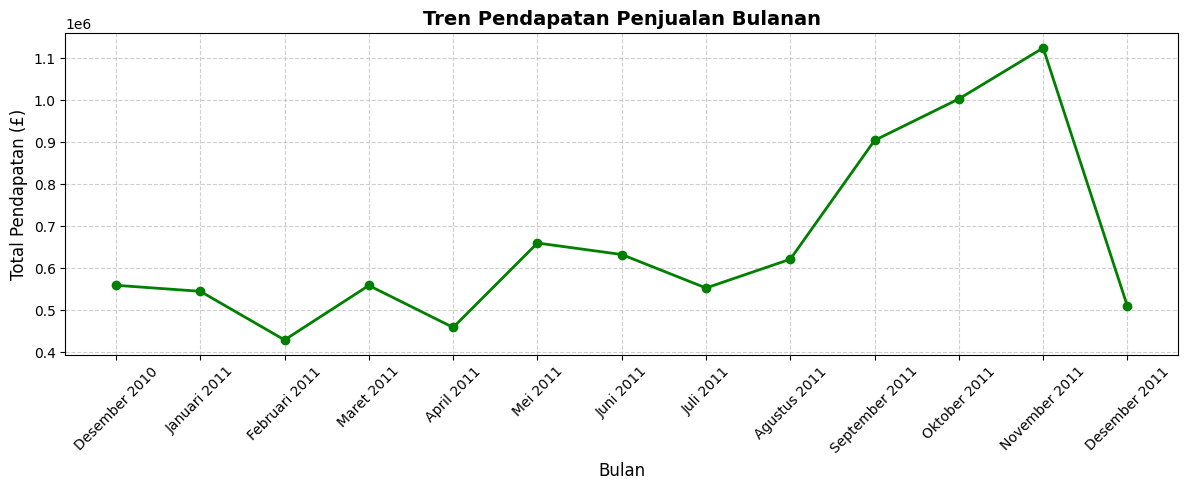

[+] Puncak Penjualan Tertinggi : November 2011 (Total £1,124,598.50)
[-] Titik Penjualan Terendah   : Februari 2011 (Total £429,738.24)


In [23]:
# =====================================================================
# 2. ANALISIS TREN PENJUALAN UMUM
# =====================================================================
print("-" * 60)
print("B. HASIL ANALISIS TREN PENJUALAN")
print("-" * 60)

# Mengelompokkan pendapatan
tren = sales_df.groupby(['Periode_Sistem', 'Bulan_Tahun'])['Revenue'].sum().reset_index()

# Grafik Garis
plt.figure(figsize=(12, 5))
plt.plot(tren['Bulan_Tahun'], tren['Revenue'], marker='o', color='green', linewidth=2)
plt.title('Tren Pendapatan Penjualan Bulanan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Pendapatan (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

bulan_tertinggi = tren.loc[tren['Revenue'].idxmax()]
bulan_terendah = tren.loc[tren['Revenue'].idxmin()]

print(f"[+] Puncak Penjualan Tertinggi : {bulan_tertinggi['Bulan_Tahun']} (Total £{bulan_tertinggi['Revenue']:,.2f})")
print(f"[-] Titik Penjualan Terendah   : {bulan_terendah['Bulan_Tahun']} (Total £{bulan_terendah['Revenue']:,.2f})")

------------------------------------------------------------
C. ANALISIS PRODUK TERLARIS & TERENDAH TIAP BULAN
------------------------------------------------------------


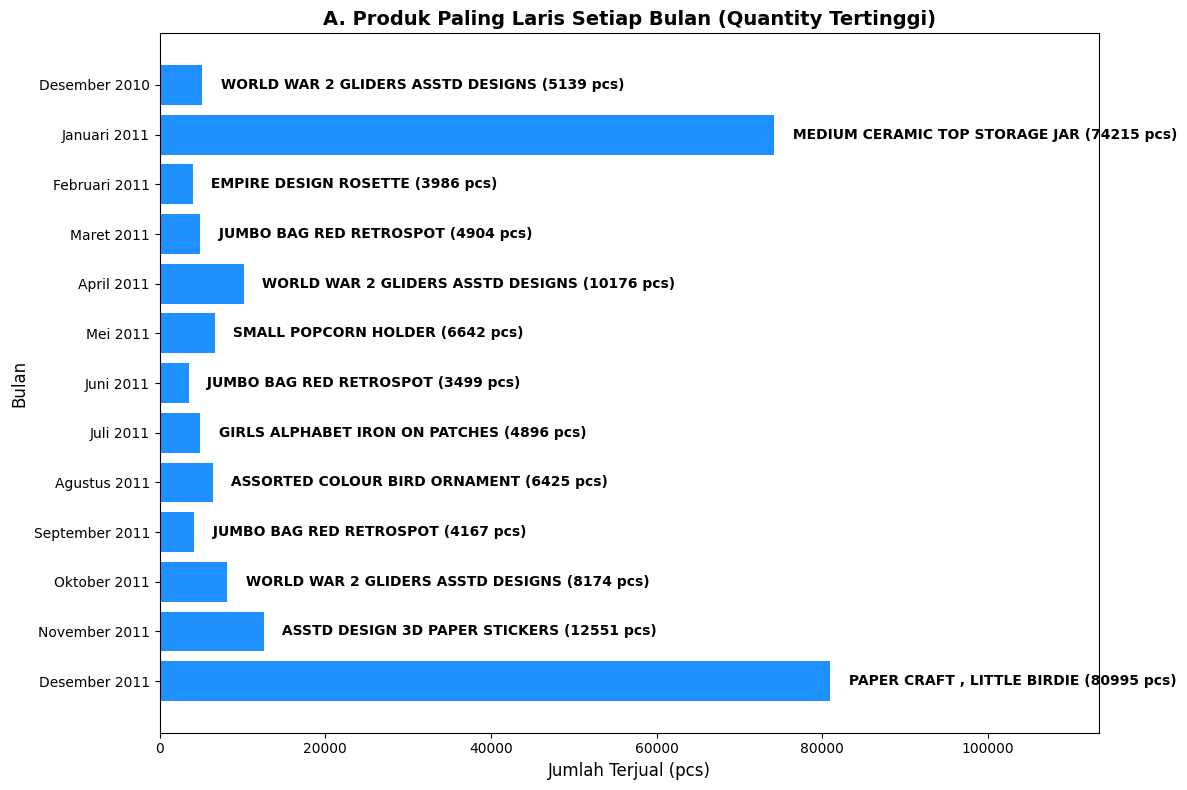

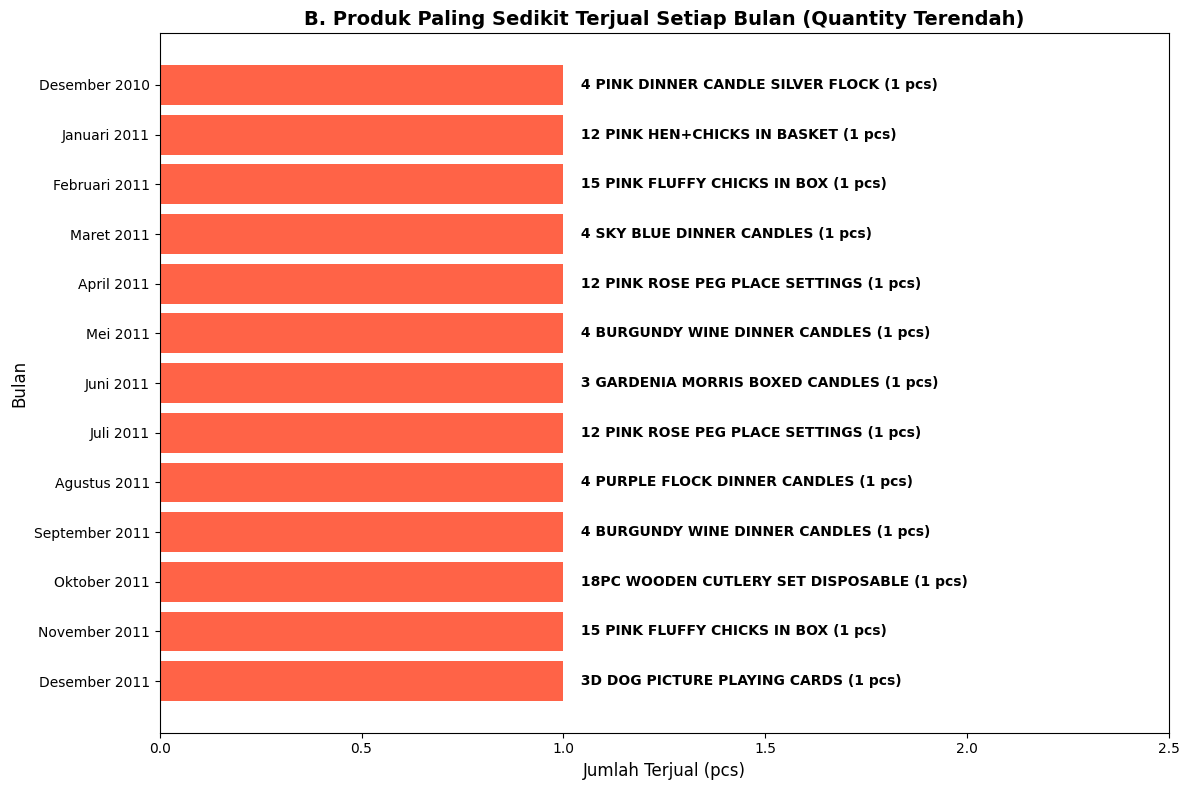

In [30]:
# =====================================================================
# 3. ANALISIS PRODUK TERLARIS & TERENDAH TIAP BULAN
# =====================================================================
print("-" * 60)
print("C. ANALISIS PRODUK TERLARIS & TERENDAH TIAP BULAN")
print("-" * 60)

# Menghitung barang terjual tiap bulan (Quantity) per nama barang
item_bulanan = sales_df.groupby(['Periode_Sistem', 'Bulan_Tahun', 'Itemname'])['Quantity'].sum().reset_index()

# Menyiapkan list kosong untuk menampung data pemenang dan yang paling sedikit terjual
terlaris_list = []
terendah_list = []

# Looping melalui setiap bulan yang tersedia untuk mencari yang tertinggi dan terendah
for periode in sorted(item_bulanan['Periode_Sistem'].unique()):
    data_bulan_ini = item_bulanan[item_bulanan['Periode_Sistem'] == periode]

    # Mencari produk dengan Quantity maksimal dan minimal
    terlaris_list.append(data_bulan_ini.loc[data_bulan_ini['Quantity'].idxmax()])
    terendah_list.append(data_bulan_ini.loc[data_bulan_ini['Quantity'].idxmin()])

# Mengubah hasil list menjadi DataFrame baru yang rapi
df_terlaris = pd.DataFrame(terlaris_list)
df_terendah = pd.DataFrame(terendah_list)


# GRAFIK 1: PRODUK TERLARIS
plt.figure(figsize=(12, 8))
bars_laris = plt.barh(df_terlaris['Bulan_Tahun'], df_terlaris['Quantity'], color='dodgerblue')

max_laris = df_terlaris['Quantity'].max()
plt.xlim(0, max_laris * 1.4)

for bar, nama_item, qty in zip(bars_laris, df_terlaris['Itemname'], df_terlaris['Quantity']):
    nama_pendek = textwrap.shorten(str(nama_item), width=35, placeholder="...")
    plt.text(bar.get_width() + (max_laris * 0.02), bar.get_y() + bar.get_height()/2,
             f" {nama_pendek} ({qty} pcs)",
             va='center', ha='left', fontsize=10, fontweight='bold', color='black')

plt.title('A. Produk Paling Laris Setiap Bulan (Quantity Tertinggi)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Terjual (pcs)', fontsize=12)
plt.ylabel('Bulan', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# GRAFIK 2: PRODUK PALING SEDIKIT TERJUAL (Batang Merah)
plt.figure(figsize=(12, 8))
bars_rendah = plt.barh(df_terendah['Bulan_Tahun'], df_terendah['Quantity'], color='tomato')

max_rendah = df_terendah['Quantity'].max()
plt.xlim(0, max_rendah * 2.5)

for bar, nama_item, qty in zip(bars_rendah, df_terendah['Itemname'], df_terendah['Quantity']):
    nama_pendek = textwrap.shorten(str(nama_item), width=35, placeholder="...")
    plt.text(bar.get_width() + (max_rendah * 0.03), bar.get_y() + bar.get_height()/2,
             f" {nama_pendek} ({qty} pcs)",
             va='center', ha='left', fontsize=10, fontweight='bold', color='black')

plt.title('B. Produk Paling Sedikit Terjual Setiap Bulan (Quantity Terendah)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Terjual (pcs)', fontsize=12)
plt.ylabel('Bulan', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

------------------------------------------------------------
D. ANALISIS ANOMALI & OUTLIER
------------------------------------------------------------
1. ANOMALI RETUR (BARANG DIKEMBALIKAN / BATAL)
   Ditemukan 0 transaksi dengan jumlah minus.
   Potensi pendapatan yang hilang akibat retur sebesar £0.00.

2. OUTLIER / TRANSAKSI EKSTREM (PARTAI BESAR)
   Rata-rata pendapatan normal per transaksi hanya: £22.07
   Ditemukan 389 transaksi ekstrem di luar kebiasaan normal.
   Transaksi tertinggi bernilai sangat fantastis, yaitu £168,469.60 dalam satu pesanan!



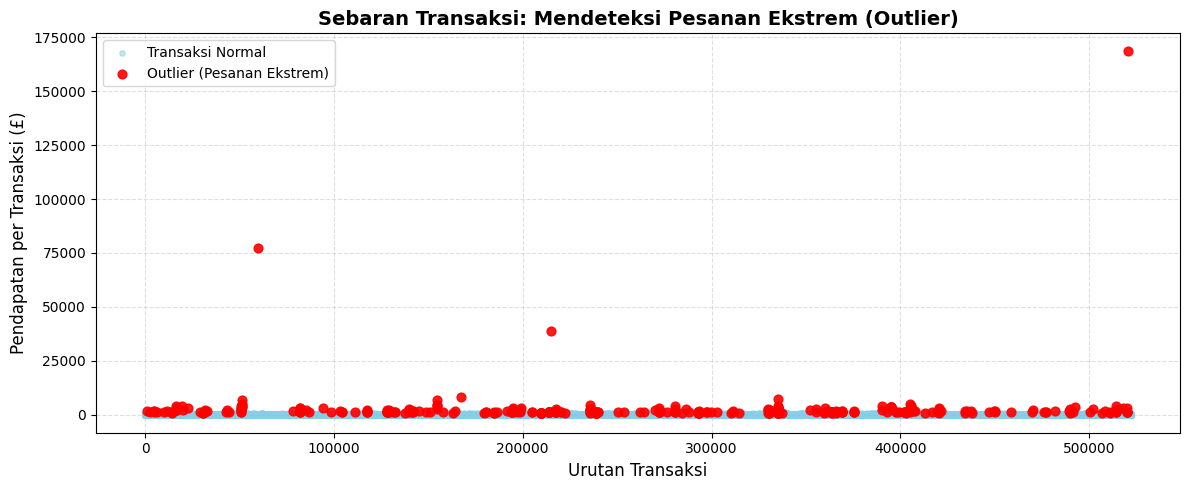

In [26]:
# =====================================================================
# 4. ANALISIS ANOMALI & OUTLIER
# =====================================================================
print("-" * 60)
print("D. ANALISIS ANOMALI & OUTLIER")
print("-" * 60)

# 1. Anomali Retur Barang
total_retur = len(retur_df)
kerugian_retur = retur_df['Revenue'].sum()

print("1. ANOMALI RETUR (BARANG DIKEMBALIKAN / BATAL)")
print(f"   Ditemukan {total_retur} transaksi dengan jumlah minus.")
print(f"   Potensi pendapatan yang hilang akibat retur sebesar £{abs(kerugian_retur):,.2f}.\n")

# 2. Outlier Transaksi (Pembelian Ekstrem)
rata_rata = sales_df['Revenue'].mean()
batas_outlier = sales_df['Revenue'].quantile(0.999) # Mengambil batas 0.1% tertinggi

# Memisahkan mana yang normal dan mana yang outlier ekstrem
outlier_df = sales_df[sales_df['Revenue'] > batas_outlier]
normal_df = sales_df[sales_df['Revenue'] <= batas_outlier]

print("2. OUTLIER / TRANSAKSI EKSTREM (PARTAI BESAR)")
print(f"   Rata-rata pendapatan normal per transaksi hanya: £{rata_rata:,.2f}")
print(f"   Ditemukan {len(outlier_df)} transaksi ekstrem di luar kebiasaan normal.")
print(f"   Transaksi tertinggi bernilai sangat fantastis, yaitu £{outlier_df['Revenue'].max():,.2f} dalam satu pesanan!\n")

# GRAFIK SCATTER PLOT
plt.figure(figsize=(12, 5))

#  Titik biru untuk transaksi normal
plt.scatter(normal_df.index, normal_df['Revenue'], color='skyblue', alpha=0.5, s=15, label='Transaksi Normal')

# Titik merah untuk transaksi ekstrem / outlier
plt.scatter(outlier_df.index, outlier_df['Revenue'], color='red', alpha=0.9, s=40, label='Outlier (Pesanan Ekstrem)', zorder=5)

plt.title('Sebaran Transaksi: Mendeteksi Pesanan Ekstrem (Outlier)', fontsize=14, fontweight='bold')
plt.xlabel('Urutan Transaksi', fontsize=12)
plt.ylabel('Pendapatan per Transaksi (£)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()